In [172]:
# Импортируем библиотеки
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_palette('husl')
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split

In [115]:
# Присвоим переменной «url» ссылку на датасет:

url = '/content/global_cars_dataset_synthetic.csv'

# создаем лист с названием столбцов:

cols = ['Car_ID', 'Brand', 'Manufacture_Year', 'Body_Type', 'Fuel_Type', 'Transmission', 'Engine_CC', 'Horsepower', 'Mileage_km_per_l', 'Price_USD', 'Manufacturing_Country']
# используем Pandas read_csv():

dataset = pd.read_csv(url, names = cols)

In [116]:
dataset = pd.read_csv(url, names=cols, skiprows=1)

In [117]:
vals = dataset["Manufacture_Year"].unique()
vals

array([2006, 2023, 2007, 2013, 2009, 2012, 2011, 2016, 2017, 2020, 2025,
       2019, 2014, 2010, 2005, 2022, 2021, 2024, 2008, 2018, 2015])

In [143]:
# сохраняем только числовые столбцы. Категориальные кодируем в числовые. Целевую переменную (если она есть) - убираем
cols_for_clusters = [ 'Manufacture_Year', 'Body_Type', 'Fuel_Type', 'Transmission', 'Engine_CC', 'Horsepower', 'Mileage_km_per_l', 'Price_USD', 'Manufacturing_Country']

df= dataset[cols_for_clusters].copy() # делаем копию, чтобы не было сюрпризов с исходным набором данных

Метод главных компонентов (Principal Component Analysis, PCA)


Principal Component Analysis(PCA) один из самых популярных методов линейного уменьшения размерности. Иногда он используется отдельно, а иногда как начальное решение для других методов уменьшения размерности.

PCA — это метод на основе проекций, который часто используется для уменьшения размерности больших наборов данных путем преобразования большого набора переменных в меньший, который по-прежнему содержит большую часть информации о большом наборе.

In [119]:
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.decomposition import PCA

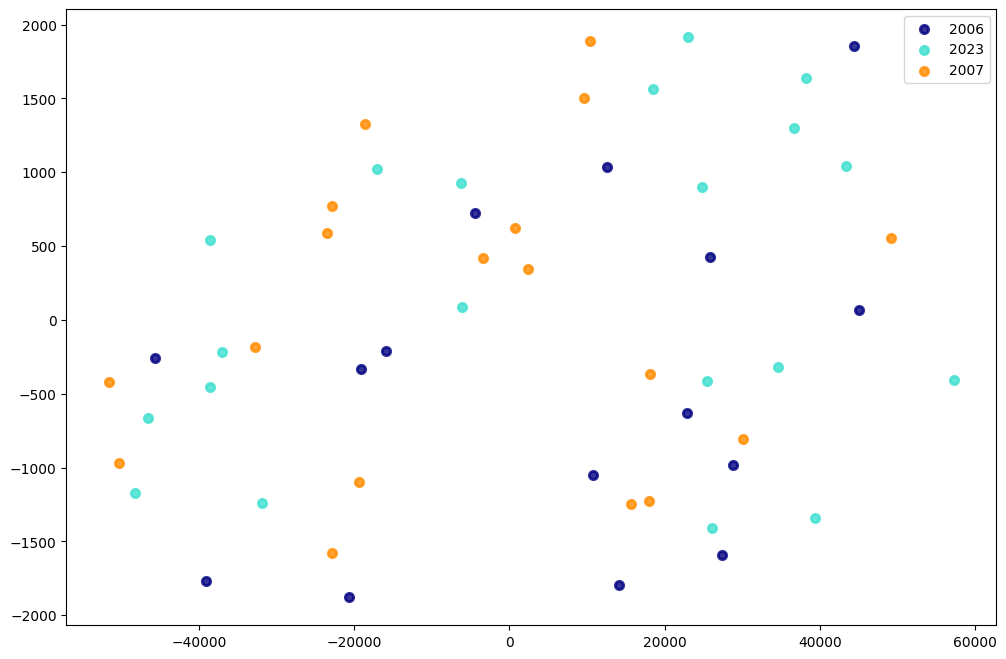

In [146]:
# Выбираем только числовые колонки
numeric_columns = X.select_dtypes(include=['int64', 'float64']).columns
X_numeric = X[numeric_columns]

pca = PCA(n_components=2)
X_new = pca.fit(X_numeric).transform(X_numeric)

plt.figure(figsize=(12,8))
colors = ["navy", "turquoise", "darkorange"]
lw = 2

for color, i, target_name in zip(colors, [0, 1, 2], cols_for_clusters):
    plt.scatter(
        X_new[y == i, 0], X_new[y == i, 1], color=color, alpha=0.8, lw=lw, label=vals[i]
    )

plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.show()

Очень полезной функцией для оценки того, насколько каждый главный компонент сохраняет информацию о дисперсии наших данных, является функция explained_variance_ratio.

In [121]:
pca.explained_variance_ratio_

array([0.99892818, 0.00105224])

 Первые главные компоненты сохраняют 99% дисперсии набора данных, тогда как вторые главные компоненты сохраняют только 0,11% дисперсии.

Независисый анализ компонентов (Independent Component Analysis, ICA)



ICA — это метод снижения размерности, аналогичный PCA в том смысле, что он берет набор признаков и создает другой набор, который полезен в некотором роде.

Применение ICA
Одним из интересных применений ICA является анализ электроэнцефалографических данных (данных из мозга). ICA является важным инструментом в нейровизуализации, фМРТ и анализе ЭЭГ, который помогает отделить нормальные сигналы от аномальных.

In [122]:
from sklearn.decomposition import FastICA

# Берем только числовые колонки
X_numeric = X.select_dtypes(include=['int64', 'float64'])

fast_ica = FastICA(n_components=2)
X_new = fast_ica.fit_transform(X_numeric)

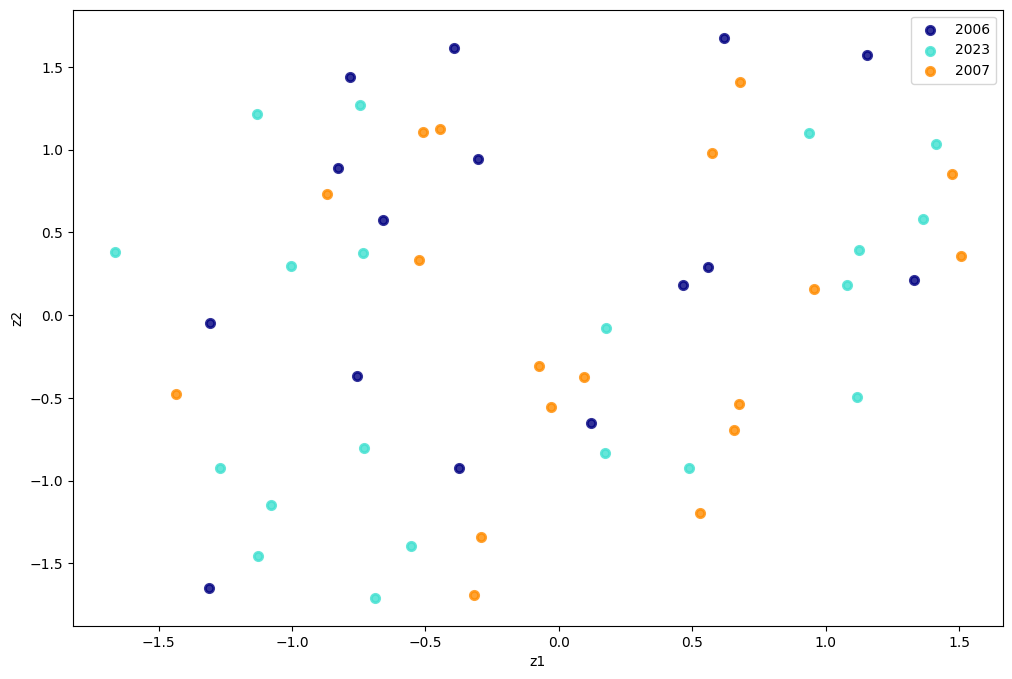

In [123]:
plt.figure(figsize=(12,8))
colors = ["navy", "turquoise", "darkorange"]
lw = 2

for color, i, target_name in zip(colors, [0, 1, 2], cols_for_clusters):
    plt.scatter(
        X_new[y == i, 0], X_new[y == i, 1], color=color, alpha=0.8, lw=lw, label=vals[i]
    )

plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()

Нелинейные методы уменьшения размерности


Методы нелинейного преобразования, также известные как методы многообразного обучения, используются, когда данные не лежат в линейном подпространстве. Она основана на гипотезе многообразия, которая гласит, что в многомерной структуре большая часть релевантной информации концентрируется в небольшом числе многообразий низкой размерности.

Если линейное подпространство представляет собой плоский лист бумаги, то свернутый лист бумаги является простым примером нелинейного многообразия. Неформально это называется швейцарским валом, канонической проблемой в области нелинейного уменьшения размерности.

Kernel PCA

In [124]:
from sklearn.decomposition import KernelPCA

# Берем только числа
X_numeric = X.select_dtypes(include=['int64', 'float64'])

rbf_pca = KernelPCA(n_components=2, kernel='rbf', gamma=0.04)
X_new = rbf_pca.fit_transform(X_numeric)

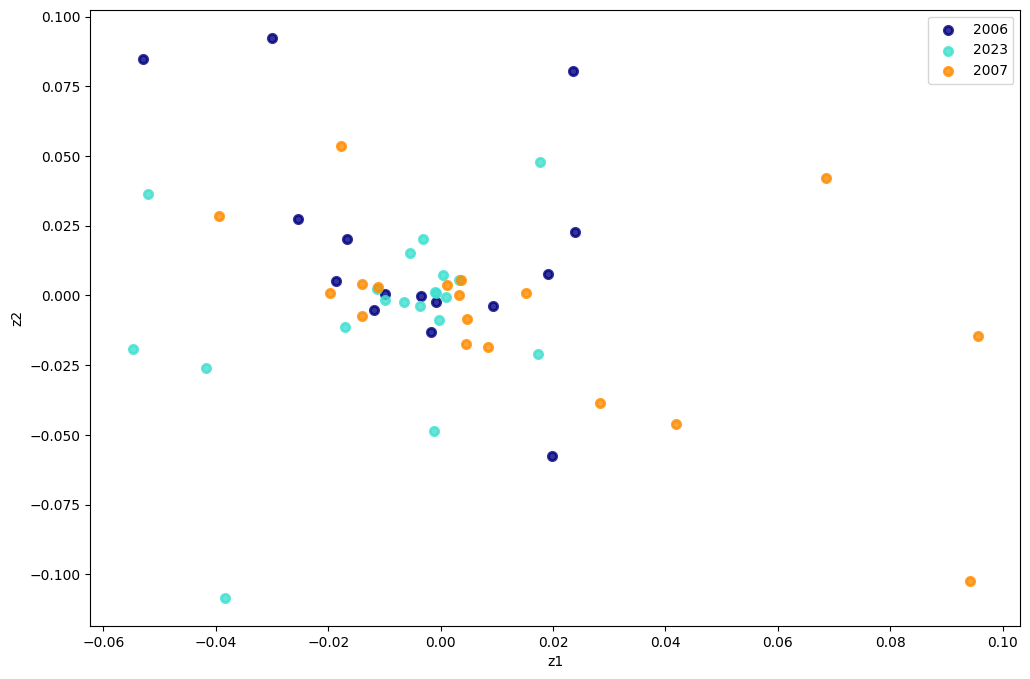

In [125]:
plt.figure(figsize=(12,8))
colors = ["navy", "turquoise", "darkorange"]
lw = 2

for color, i, target_name in zip(colors, [0, 1, 2], cols_for_clusters):
    plt.scatter(
        X_new[y == i, 0], X_new[y == i, 1], color=color, alpha=0.8, lw=lw, label=vals[i]
    )

plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()

Использование в Python

In [126]:
from sklearn.manifold import TSNE

# Берем только числа
X_numeric = X.select_dtypes(include=['int64', 'float64'])

rbf_pca = KernelPCA(n_components=2, kernel='rbf', gamma=0.04)
X_new = rbf_pca.fit_transform(X_numeric)

In [127]:
# Вывод результатов
print('Initial Shape of X: ', X.shape)
print('New Shape of X: ', X_new.shape)


Initial Shape of X:  (300, 9)
New Shape of X:  (300, 2)


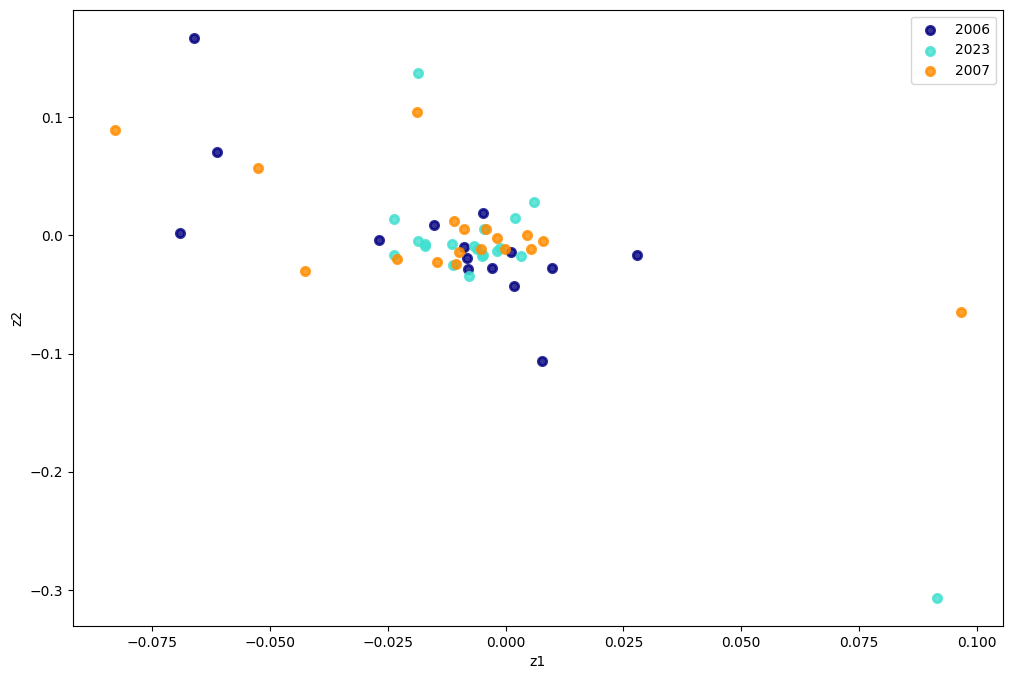

In [128]:
plt.figure(figsize=(12,8))
colors = ["navy", "turquoise", "darkorange"]
lw = 2

for color, i, target_name in zip(colors, [0, 1, 2], cols_for_clusters):
    plt.scatter(
        X_new[y == i, 0], X_new[y == i, 1], color=color, alpha=0.8, lw=lw, label=vals[i]
    )

plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()

График показывает результаты снижения размерности

DBSCAN для кластеризации

In [129]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.metrics import v_measure_score

In [130]:
# Number of Clusters
labels=dbscan_cluster1.labels_
N_clus=len(set(labels))-(1 if -1 in labels else 0)
print('Estimated no. of clusters: %d' % N_clus)

# Identify Noise
n_noise = list(dbscan_cluster1.labels_).count(-1)
print('Estimated no. of noise points: %d' % n_noise)

# Calculating v_measure
print('v_measure =', v_measure_score(y, labels))

Estimated no. of clusters: 0
Estimated no. of noise points: 300
v_measure = 0.0



Estimated no. of clusters: 0 - алгоритм не нашел ни одного кластера

Estimated no. of noise points: 300 - все 300 точек определены как шум

v_measure = 0.0 - полное несоответствие с реальными метками (y)

/tmp/ipykernel_243/3525601781.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="best", shadow=False, scatterpoints=2)


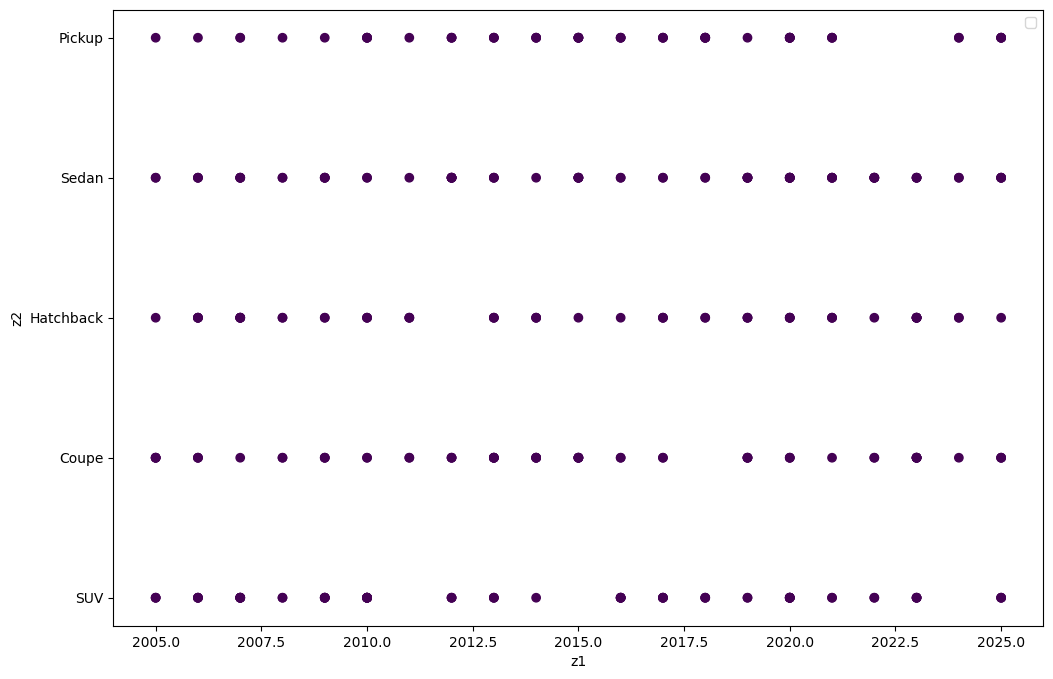

In [133]:
plt.figure(figsize=(12,8))
colors = ["navy", "turquoise", "darkorange"]
lw = 2

plt.scatter(
        X[cols[2]], X[cols[3]],c=dbscan_cluster1.labels_
    )

plt.legend(loc="best", shadow=False, scatterpoints=2)
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()

Данные охватывают все типы кузова и все годы выпуска. Каждая точка представляет автомобиль с определенным типом кузова и годом выпуска

In [137]:
from sklearn.neighbors import NearestNeighbors

min_samples = 3
# Берем только числовые колонки
X_numeric = X.select_dtypes(include=['int64', 'float64'])

knn = NearestNeighbors(n_neighbors=min_samples, metric='l2')
knn.fit(X_numeric)

dists, inds = knn.kneighbors(X_numeric)
dists_ar = dists[:, 1:min_samples].mean(axis=1)
dists_ar.sort()

In [138]:
import sklearn
#возможные метрики расстояния
sklearn.metrics.pairwise.distance_metrics()

{'cityblock': <function sklearn.metrics.pairwise.manhattan_distances(X, Y=None)>,
 'cosine': <function sklearn.metrics.pairwise.cosine_distances(X, Y=None)>,
 'euclidean': <function sklearn.metrics.pairwise.euclidean_distances(X, Y=None, *, Y_norm_squared=None, squared=False, X_norm_squared=None)>,
 'haversine': <function sklearn.metrics.pairwise.haversine_distances(X, Y=None)>,
 'l2': <function sklearn.metrics.pairwise.euclidean_distances(X, Y=None, *, Y_norm_squared=None, squared=False, X_norm_squared=None)>,
 'l1': <function sklearn.metrics.pairwise.manhattan_distances(X, Y=None)>,
 'manhattan': <function sklearn.metrics.pairwise.manhattan_distances(X, Y=None)>,
 'precomputed': None,
 'nan_euclidean': <function sklearn.metrics.pairwise.nan_euclidean_distances(X, Y=None, *, squared=False, missing_values=nan, copy=True)>}

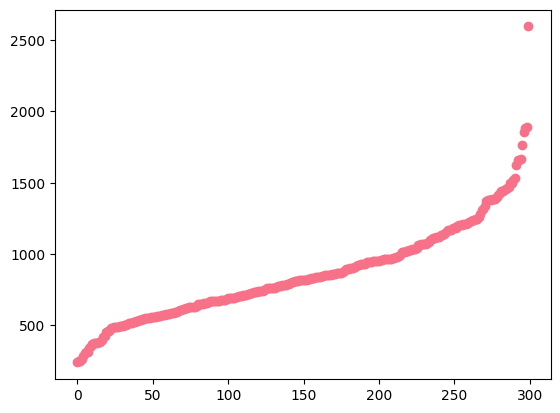

In [139]:
plt.scatter(x = range(len(dists_ar)), y=dists_ar)
plt.show()

Оптимальный eps выбирается в месте изгиба графика там, где расстояния начинают резко расти

Для моих данных это значение примерно 500-1000



DBSCAN для определения выбросов

In [164]:
dbscan = DBSCAN(eps = 0.5, min_samples = min_samples)
print(dbscan)

DBSCAN(min_samples=3)


In [167]:
from sklearn.preprocessing import LabelEncoder

# Преобразуем текстовые данные в числа
X_encoded = X.copy()
for col in X_encoded.columns:
    if X_encoded[col].dtype == 'object':
        X_encoded[col] = LabelEncoder().fit_transform(X_encoded[col].astype(str))

pred = dbscan.fit_predict(X_encoded)

In [168]:
# Number of Clusters
labels=dbscan.labels_
N_clus=len(set(labels))-(1 if -1 in labels else 0)
print('Estimated no. of clusters: %d' % N_clus)

# Identify Noise
n_noise = list(dbscan.labels_).count(-1)
print('Estimated no. of noise points: %d' % n_noise)

# Calculating v_measure
print('v_measure =', v_measure_score(y, labels))

Estimated no. of clusters: 0
Estimated no. of noise points: 300
v_measure = 0.0


In [169]:
# у анномалий - класс -1, ищем все номера строк с таким классом, потом отбираем эти строки из начального набора данных

anom_index = [i for i in range(len(pred)) if pred[i] == -1]
values = X.loc[anom_index]

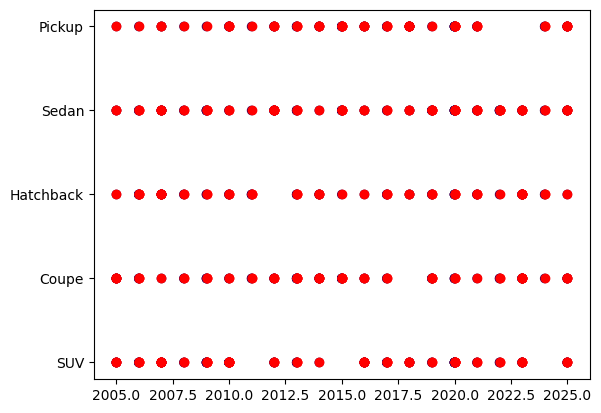

In [171]:
plt.scatter( X[cols[2]], X[cols[3]],c=dbscan_cluster1.labels_)
plt.scatter(values[cols[2]], values[cols[3]], color='r')
plt.show()

График показывает кластеризацию автомобилей по годам выпуска и типам кузова